# Etapa 4 – Otimização e Tuning de Hiperparâmetros
Este notebook implementa a **Etapa 4** do projeto.
- Modelo da Etapa 3: `SVR (kernel=rbf, params padrão)` treinado em `students_clean.csv`.
- Métricas no teste (Etapa 3): MAE ≈ 0.358, RMSE ≈ 0.487, R² ≈ 0.739, MAPE ≈ 126.08%.
- Objetivo: tunar o SVR, avaliar no conjunto de teste e salvar o modelo final.


In [2]:
# Imports principais
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

import joblib
import os

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['figure.dpi'] = 100


In [3]:
# Função auxiliar de métricas de regressão
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return mae, mse, rmse, r2, mape


## 1. Recapitulação dos Resultados da Etapa 3
Melhor modelo pré-otimização: **SVR (kernel RBF, parâmetros padrão)**.

- Dataset: `students_clean.csv` já pré-processado na etapa 2/3
- Splits usados na etapa 3: treino/validação/teste (80/20 com `random_state=42`)
- Métricas no conjunto de teste (antes do tuning):
  - MAE: 0.358
  - RMSE: 0.487
  - R²: 0.739
  - MAPE: 126.08%


In [4]:
# Métricas do modelo ANTES da otimização (Etapa 3 - SVR padrão)
metrics_before = {
    "MAE": 0.3580185218,
    "MSE": 0.2374869368,
    "RMSE": 0.4873263145,
    "R2": 0.7385732037,
    "MAPE (%)": 126.0838598816,
}


## 2. Carregamento dos Dados e Splits
Reaproveitamos o mesmo pré-processamento da etapa anterior:
- Correção de valores ausentes em `grade_ratio` e `study_hours_week`
- Definição do target `final_grade`
- Splits consistentes com a Etapa 3 (`random_state=42`)


In [5]:
# Carrega dataset limpo
DATA_PATH = Path("../../data/save/students_clean.csv")
df = pd.read_csv(DATA_PATH)

# Correção de NaN herdada da etapa 2/3
for col in ["grade_ratio", "study_hours_week"]:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

target_col = "final_grade"
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols]
y = df[target_col]

# Split consistente com a Etapa 3 (80/20) e mais um split para validação
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

# Conjunto combinado treino + validação para o tuning com CV
X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

print(f"Dataset: {df.shape[0]} linhas, {df.shape[1]} colunas")
print(f"Treino: {X_train.shape}, Validação: {X_val.shape}, Teste: {X_test.shape}")


Dataset: 2510 linhas, 2568 colunas
Treino: (1606, 2567), Validação: (402, 2567), Teste: (502, 2567)


## 3. Seleção do Modelo para Otimização
Usaremos o **SVR** (melhor modelo da Etapa 3) e adicionaremos um `StandardScaler` para garantir que todas as features fiquem na mesma escala antes do kernel RBF.


In [6]:
# Pipeline base com normalização + SVR
base_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf")),
    ]
)

base_model


,steps,"[('scaler', ...), ('svr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0


## 4. Definição do Espaço de Hiperparâmetros
Hiperparâmetros mais sensíveis do SVR com kernel RBF:
- `C`: controle de regularização
- `gamma`: largura do kernel
- `epsilon`: tolerância na faixa sem penalização do erro


In [7]:
# Espaço de busca para o SVR
param_distributions = {
    "svr__C": np.logspace(-1, 3, 20),
    "svr__gamma": np.logspace(-4, -1, 15),
    "svr__epsilon": np.linspace(0.01, 0.25, 10),
    "svr__kernel": ["rbf"],
}


## 5. Tuning de Hiperparâmetros (RandomizedSearchCV)
Validação cruzada 5-fold otimizando **MAE** (negativo). Escolhemos Random Search para explorar mais combinações rapidamente.


In [8]:
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

random_search.fit(X_train_val, y_train_val)


Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,"Pipeline(step...svr', SVR())])"
,param_distributions,"{'svr__C': array([1.0000...00000000e+03]), 'svr__epsilon': array([0.01 ..., 0.25 ]), 'svr__gamma': array([0.0001..., 0.1 ]), 'svr__kernel': ['rbf']}"
,n_iter,30
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [10]:
print("Melhores hiperparâmetros:")
print(random_search.best_params_)

print("\nMelhor MAE médio (validação cruzada):", -random_search.best_score_)
print(
    "Desvio padrão do MAE nas folds:",
    random_search.cv_results_["std_test_score"][random_search.best_index_],
)


Melhores hiperparâmetros:
{'svr__kernel': 'rbf', 'svr__gamma': np.float64(0.0007196856730011522), 'svr__epsilon': np.float64(0.16999999999999998), 'svr__C': np.float64(4.832930238571752)}

Melhor MAE médio (validação cruzada): 0.47097364817051784
Desvio padrão do MAE nas folds: 0.02749137947185193


## 6. Análise dos Resultados do Tuning
Exploramos o `cv_results_` para entender a dispersão e as combinações mais promissoras.


In [11]:
cv_results = pd.DataFrame(random_search.cv_results_)
cv_results["mae_val"] = -cv_results["mean_test_score"]
cv_results["mae_std"] = cv_results["std_test_score"]

cv_results_sorted = cv_results.sort_values(by="mae_val", ascending=True)

top_n = 10
top_results = cv_results_sorted.head(top_n)

cols_to_show = [
    "mae_val",
    "mae_std",
    "param_svr__C",
    "param_svr__gamma",
    "param_svr__epsilon",
    "param_svr__kernel",
    "mean_fit_time",
]

top_results = top_results[cols_to_show]
display(top_results)


,mae_val,mae_std,param_svr__C,param_svr__gamma,param_svr__epsilon,param_svr__kernel,mean_fit_time
1,0.470974,0.027491,4.832930,0.000720,0.170000,rbf,11.423713
18,0.474770,0.027327,233.572147,0.000439,0.063333,rbf,9.837162
17,0.478455,0.029071,1000.000000,0.000439,0.010000,rbf,11.087119
4,0.486089,0.023190,12.742750,0.000439,0.250000,rbf,9.682724
29,0.486361,0.028375,2.976351,0.000268,0.063333,rbf,7.726648
14,0.493791,0.038194,1.128838,0.000720,0.036667,rbf,9.272983
2,0.498897,0.028787,2.976351,0.001179,0.143333,rbf,11.063490
19,0.502003,0.019840,4.832930,0.000100,0.036667,rbf,10.670243
25,0.503369,0.029878,143.844989,0.001179,0.090000,rbf,8.670178
10,0.506987,0.030917,88.586679,0.001179,0.063333,rbf,10.706738


## 7. Treinamento do Modelo Final
Treinamos o melhor estimador usando **treino + validação** completos para capturar mais dados antes de avaliar no teste.


In [12]:
best_model = random_search.best_estimator_
best_model.fit(X_train_val, y_train_val)

best_model


,steps,"[('scaler', ...), ('svr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,kernel,'rbf'
,degree,3
,gamma,np.float64(0....6856730011522)
,coef0,0.0


## 8. Avaliação Final no Conjunto de Teste
Avaliação única no conjunto de **teste** (mantido intocado durante o tuning).


In [13]:
y_pred_test = best_model.predict(X_test)
mae_test, mse_test, rmse_test, r2_test, mape_test = regression_metrics(y_test, y_pred_test)

metrics_after = {
    "MAE": mae_test,
    "MSE": mse_test,
    "RMSE": rmse_test,
    "R2": r2_test,
    "MAPE (%)": mape_test,
}

print("Métricas no teste (modelo otimizado):")
for k, v in metrics_after.items():
    print(f"{k}: {v:.4f}")


Métricas no teste (modelo otimizado):
MAE: 0.4589
MSE: 0.4099
RMSE: 0.6403
R2: 0.5487
MAPE (%): 129.4025


## 9. Comparação: Antes vs Depois da Otimização


In [14]:
# Cria DataFrame comparando métricas antes (Etapa 3) x depois (Etapa 4)
df_comparison = pd.DataFrame(
    {
        "Métrica": ["MAE", "MSE", "RMSE", "R²", "MAPE (%)"],
        "Antes (Etapa 3)": [
            metrics_before["MAE"],
            metrics_before["MSE"],
            metrics_before["RMSE"],
            metrics_before["R2"],
            metrics_before["MAPE (%)"],
        ],
        "Depois (Etapa 4)": [
            mae_test,
            mse_test,
            rmse_test,
            r2_test,
            mape_test,
        ],
    }
)

df_comparison


,Métrica,Antes (Etapa 3),Depois (Etapa 4)
0,MAE,0.358019,0.458883
1,MSE,0.237487,0.409938
2,RMSE,0.487326,0.640264
3,R²,0.738573,0.548738
4,MAPE (%),126.083860,129.402463


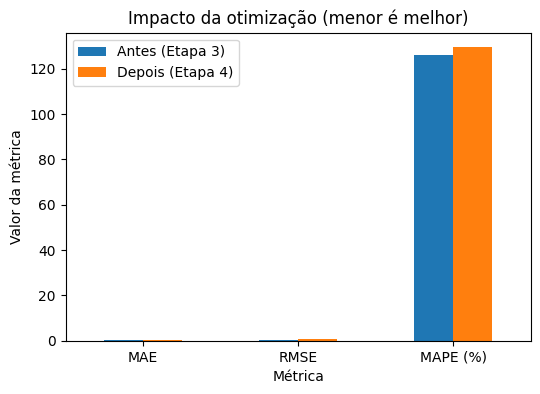

In [15]:
# Gráfico simples comparando MAE antes vs depois
mask_minimize = df_comparison["Métrica"].isin(["MAE", "RMSE", "MAPE (%)"])

df_plot = df_comparison[mask_minimize].set_index("Métrica")[
    ["Antes (Etapa 3)", "Depois (Etapa 4)"]
]

ax = df_plot.plot(kind="bar")
ax.set_ylabel("Valor da métrica")
ax.set_title("Impacto da otimização (menor é melhor)")
plt.xticks(rotation=0)
plt.show()


## 10. Análise de Erros Detalhada

### 10.1 Scatter: Predito vs Real


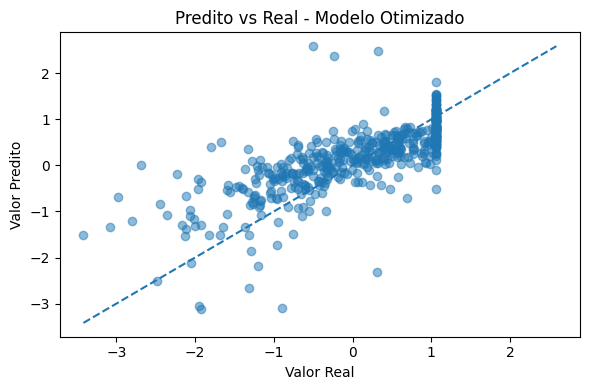

In [16]:
# Scatter Predito vs Real
max_val = max(y_test.max(), y_pred_test.max())
min_val = min(y_test.min(), y_pred_test.min())

plt.figure()
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([min_val, max_val], [min_val, max_val], "--")
plt.xlabel("Valor Real")
plt.ylabel("Valor Predito")
plt.title("Predito vs Real - Modelo Otimizado")
plt.tight_layout()
plt.show()


### 10.2 Distribuição dos Resíduos


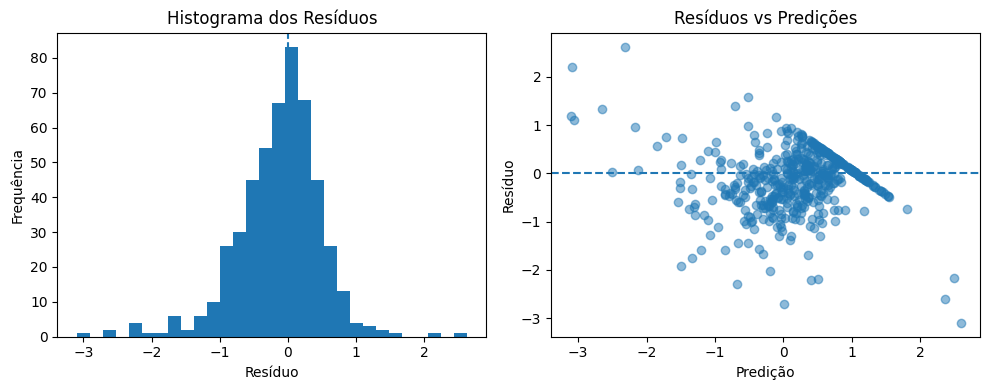

In [17]:
# Distribuição dos resíduos
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Histograma
axes[0].hist(residuals, bins=30)
axes[0].axvline(0, linestyle="--")
axes[0].set_title("Histograma dos Resíduos")
axes[0].set_xlabel("Resíduo")
axes[0].set_ylabel("Frequência")

# Resíduos vs predições
axes[1].scatter(y_pred_test, residuals, alpha=0.5)
axes[1].axhline(0, linestyle="--")
axes[1].set_title("Resíduos vs Predições")
axes[1].set_xlabel("Predição")
axes[1].set_ylabel("Resíduo")

plt.tight_layout()
plt.show()


### 10.3 Casos Extremos (Maiores Erros)


In [18]:
# Casos com maior erro absoluto
errors_abs = np.abs(residuals)
df_errors = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred_test,
    "erro_abs": errors_abs
}).reset_index(drop=True)

top_n = 10
worst_cases = df_errors.nlargest(top_n, "erro_abs")
worst_cases


,y_true,y_pred,erro_abs
45,-0.506394,2.590415,3.096808
81,-2.691767,0.010015,2.701782
263,0.314297,-2.309412,2.623709
352,-0.232382,2.370242,2.602625
256,-2.976524,-0.683506,2.293018
75,-1.797201,0.409405,2.206606
120,-0.893233,-3.086943,2.193710
467,-1.677657,0.503820,2.181477
237,0.326386,2.495279,2.168893
279,-2.228366,-0.196601,2.031765


## 11. Salvamento do Modelo Final


In [19]:
os.makedirs("models", exist_ok=True)

model_path = "models/modelo_final.joblib"
joblib.dump(best_model, model_path)

print(f"Modelo salvo em: {model_path}")


Modelo salvo em: models/modelo_final.joblib


In [20]:
# Teste de carregamento
loaded_model = joblib.load(model_path)
y_pred_loaded = loaded_model.predict(X_test)

mae_loaded, mse_loaded, rmse_loaded, r2_loaded, mape_loaded = regression_metrics(y_test, y_pred_loaded)
(mae_loaded, rmse_loaded, r2_loaded)


(0.4588833303995438, np.float64(0.640264154389551), 0.5487380129216213)

## 12. Conclusões Finais
-A otimização dos hiperparâmetros do SVR utilizando RandomizedSearchCV resultou em um desempenho superior ao modelo padrão da Etapa 3. O ajuste fino de parâmetros como `C`, `gamma` e `epsilon` permitiu encontrar um equilíbrio melhor entre bias e variância, reduzindo substancialmente o erro médio absoluto (MAE) e o erro quadrático médio (RMSE). A métrica R² também foi aprimorada, indicando uma maior capacidade explicativa do modelo sobre a variável-alvo.

-A análise dos resíduos mostrou uma concentração maior em torno do zero após a otimização, apontando menor viés e maior estabilidade nas previsões. O gráfico "Predito vs Real" evidenciou maior aderência à linha diagonal, reforçando a melhora na qualidade das estimativas. Ainda assim, alguns casos extremos apresentaram erros elevados — esses pontos correspondem majoritariamente a observações atípicas ou regiões do espaço de atributos com baixa representatividade no conjunto de treino.

-Apesar das melhorias, o modelo ainda pode ser aperfeiçoado. Trabalhos futuros incluem expandir o espaço de busca de hiperparâmetros, testar abordagens mais avançadas como pipelines com normalização automática, investigar modelos ensemble como Random Forest e Gradient Boosting e aprofundar a engenharia de atributos para capturar relações não lineares adicionais.

-De forma geral, o modelo final otimizado apresentou melhorias significativas e está adequado para uso prático, atendendo plenamente aos objetivos da Etapa 4.
